In [2]:
#pip install folium matplotlib mapclassify
#pip install geopandas

In [3]:
import geopandas as gpd
import pandas as pd
import folium
from shapely.ops import unary_union
import numpy as np
from pysimdeum.api import build_multi_hh

### Read data

In [4]:
ad_path = "/Users/val.ismaili/Downloads/ICM-WWG-project/Address_Points/address_pts.shp"
subs = "/Users/val.ismaili/Downloads/ICM-WWG-project/test-subs.shp"
oa = "/Users/val.ismaili/Downloads/Output_Areas_(December_2021)_Boundaries_EW_BFE_(V9).geojson"
oa_pop = "/Users/val.ismaili/Downloads/oa_population.csv"

ad = gpd.read_file(ad_path)
subs = gpd.read_file(subs)
oa = gpd.read_file(oa).to_crs(epsg=27700)
oa_pop = pd.read_csv(oa_pop)

/var/folders/y5/x93059_x67b9v8zzbq9x285nrqn4c0/T/ipykernel_33373/4019410419.py:9: DtypeWarning: Columns (3,23,114) have mixed types. Specify dtype option on import or set low_memory=False.
  oa_pop = pd.read_csv(oa_pop)


In [5]:
subs['geometry'] = subs['geometry'].buffer(0)

merged_subs = unary_union(subs.geometry)
merged_subs_gdf = gpd.GeoDataFrame(geometry=[merged_subs], crs=subs.crs)

# select oas of interest (overlap with sub catchments)
oa_intersected = gpd.sjoin(oa, merged_subs_gdf, how='inner', predicate='intersects')
oa_intersected = oa_intersected.drop(columns='index_right')
oa_intersected.explore()

In [6]:
# selected oas population
oa_pop = oa_pop[oa_pop['OA 2021 Code'].isin(oa_intersected['OA21CD'].unique())][['OA 2021 Code', 'Total']]
oa_pop

,OA 2021 Code,Total
11242,E00070762,330
11243,E00070763,254
11244,E00070764,223
11245,E00070765,189
11246,E00070766,292


In [7]:
# hhs within the selected oas, independent of whether they lie within a subcatchment
ad_intersected = gpd.sjoin(ad, oa_intersected, how='inner', predicate='intersects')
ad_intersected = ad_intersected.drop(columns='index_right')
ad_intersected = ad_intersected[ad_intersected['BaseFuncti'] == 'DWELLING']

In [8]:
# Create a base map using the explore method on the subs GeoDataFrame
m = oa_intersected.explore(name='oa_intersected')

# Add the ad points to the same map
ad_intersected.explore(m=m, name='ad_intersected')

# Add layer control to toggle between layers
folium.LayerControl().add_to(m)

# Display the map
m

In [9]:
# add pop totals to oa hh counts
oa_counts = ad_intersected.groupby('OA21CD').size().reset_index(name='counts')
oa_counts.rename(columns={'counts': 'household_tots'}, inplace=True)
oa_counts = oa_counts.merge(oa_pop, left_on='OA21CD', right_on='OA 2021 Code').drop(columns='OA 2021 Code').rename(columns={'Total': 'pop_tot'})
oa_counts

,OA21CD,household_tots,pop_tot
0,E00070762,146,330
1,E00070763,127,254
2,E00070764,125,223
3,E00070765,60,189
4,E00070766,128,292


### Household assignment

In [10]:
# these are manual inputs from configs hh stats
probabilities = np.array([0.30, 0.34, 0.36])
household_sizes = np.array([1, 2, 3.75])

In [11]:
total_population = float(oa_counts['pop_tot'][0])
total_households = oa_counts['household_tots'][0]
oa = oa_counts['OA21CD'][0]

#expected_households = total_households * probabilities

#households_one_person = int(round(expected_households[0]))
#households_two_person = int(round(expected_households[1]))
#households_family = int(round(expected_households[2]))

In [12]:
oa

'E00070762'

In [13]:
# Function to calculate the resulting population
def calculate_population(households, sizes):
    return np.dot(households, sizes)

# Function to adjust probabilities based on the difference
def adjust_probabilities(probs, diff, step=0.01):
    if diff > 0:
        # Increase probabilities for larger households
        probs[2] += step
        probs[1] += step / 2
        probs[0] -= step / 2
    else:
        # Increase probabilities for smaller households
        probs[0] += step
        probs[1] += step / 2
        probs[2] -= step / 2
    # Normalize probabilities to sum to 1
    probs = probs / probs.sum()
    return probs

# Iteratively adjust probabilities and resample until the resulting population matches the expected population
while True:
    # Calculate the initial number of households in each category based on probabilities
    initial_households = total_households * probabilities

    # Round the initial households to the nearest integer
    households_one_person = int(round(initial_households[0]))
    households_two_person = int(round(initial_households[1]))
    households_family = int(round(initial_households[2]))

    # Ensure the total number of households remains the same
    total_sampled_households = households_one_person + households_two_person + households_family
    if total_sampled_households != total_households:
        diff_households = total_households - total_sampled_households
        if diff_households > 0:
            # Add the difference to the category with the highest probability
            if probabilities[2] >= probabilities[1] and probabilities[2] >= probabilities[0]:
                households_family += diff_households
            elif probabilities[1] >= probabilities[0]:
                households_two_person += diff_households
            else:
                households_one_person += diff_households
        else:
            # Remove the difference from the category with the highest probability
            if probabilities[2] >= probabilities[1] and probabilities[2] >= probabilities[0] and households_family > 0:
                households_family += diff_households
            elif probabilities[1] >= probabilities[0] and households_two_person > 0:
                households_two_person += diff_households
            elif households_one_person > 0:
                households_one_person += diff_households

    # Calculate the resulting total population
    resulting_population = calculate_population(
        [households_one_person, households_two_person, households_family],
        household_sizes
    )

    # Check if the resulting population matches the expected population
    if resulting_population == total_population:
        break

    # Adjust probabilities based on the difference
    diff = total_population - resulting_population
    probabilities = adjust_probabilities(probabilities, diff)

# Display the results
print(f"Households with one person: {households_one_person}")
print(f"Households with two persons: {households_two_person}")
print(f"Households with family (3.75 persons): {households_family}")
print(f"Resulting total population: {resulting_population}")
print(f"Adjusted probabilities: {probabilities}")

Households with one person: 46
Households with two persons: 52
Households with family (3.75 persons): 48
Resulting total population: 330.0
Adjusted probabilities: [0.31768702 0.35076511 0.33154786]


In [14]:
ad_filt = ad_intersected[ad_intersected['OA21CD'] == oa]
ad_filt

,TOID,Version,VerDate,Theme,BNGEast,BNGNorth,UARN,UDPRN,UMRRN,OSAPR,...,LSOA21CD,LSOA21NM,LSOA21NMW,BNG_E,BNG_N,LAT,LONG,Shape__Area,Shape__Length,GlobalID
70847,5000005100034025,3,2013-07-18,Postal,340386.900,251502.60,None,52448871,None,AP0000000000048173,...,E01014016,Herefordshire 007D,,340879,251246,52.15632,-2.8656,471496.303825,5271.542488,aca32063-fc1f-43ab-94f0-3c99eeb393b3
70848,5000005100035696,3,2013-07-18,Postal,340562.412,251226.81,None,52082885,None,AP0000000000032354,...,E01014016,Herefordshire 007D,,340879,251246,52.15632,-2.8656,471496.303825,5271.542488,aca32063-fc1f-43ab-94f0-3c99eeb393b3
119228,1000002248076381,4,2013-07-18,Postal,340502.900,251082.80,None,51521033,None,APE56X8N57B2QEPGBA,...,E01014016,Herefordshire 007D,,340879,251246,52.15632,-2.8656,471496.303825,5271.542488,aca32063-fc1f-43ab-94f0-3c99eeb393b3
131689,5000005100027745,4,2015-03-12,Postal,340440.730,251579.77,None,52440053,None,AP0000000000040637,...,E01014016,Herefordshire 007D,,340879,251246,52.15632,-2.8656,471496.303825,5271.542488,aca32063-fc1f-43ab-94f0-3c99eeb393b3
131690,5000005106768357,4,2015-03-12,Postal,340445.800,251566.50,None,52942299,None,AP0000000000902918,...,E01014016,Herefordshire 007D,,340879,251246,52.15632,-2.8656,471496.303825,5271.542488,aca32063-fc1f-43ab-94f0-3c99eeb393b3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1617380,1000002247166296,12,2014-04-02,Postal,340244.500,251445.20,None,11008023,None,AP8TA68X56U5RK8GPA,...,E01014016,Herefordshire 007D,,340879,251246,52.15632,-2.8656,471496.303825,5271.542488,aca32063-fc1f-43ab-94f0-3c99eeb393b3
1845655,1000002247166287,15,2013-07-18,Postal,340380.400,251511.90,None,11008121,None,APQVA68X56K5RL80NA,...,E01014016,Herefordshire 007D,,340879,251246,52.15632,-2.8656,471496.303825,5271.542488,aca32063-fc1f-43ab-94f0-3c99eeb393b3
1845656,1000002247166288,15,2013-07-18,Postal,340380.400,251511.90,None,11008124,None,APQVA68X56K5RL80PA,...,E01014016,Herefordshire 007D,,340879,251246,52.15632,-2.8656,471496.303825,5271.542488,aca32063-fc1f-43ab-94f0-3c99eeb393b3
1909760,1000002247166250,17,2014-02-19,Postal,340193.000,251418.80,None,11008021,None,AP43L88X5Q05RK901A,...,E01014016,Herefordshire 007D,,340879,251246,52.15632,-2.8656,471496.303825,5271.542488,aca32063-fc1f-43ab-94f0-3c99eeb393b3


In [15]:
household_counts = {
    'one_person': households_one_person,
    'two_person': households_two_person,
    'family': households_family
}

# Shuffle the rows to ensure random assignment
ad_filt = ad_filt.sample(frac=1).reset_index(drop=True)

# Assign occupancy types
for index, row in ad_filt.iterrows():
    if household_counts['one_person'] > 0:
        ad_filt.at[index, 'occupancy_type'] = 'one_person'
        household_counts['one_person'] -= 1
    elif household_counts['two_person'] > 0:
        ad_filt.at[index, 'occupancy_type'] = 'two_person'
        household_counts['two_person'] -= 1
    elif household_counts['family'] > 0:
        ad_filt.at[index, 'occupancy_type'] = 'family'
        household_counts['family'] -= 1

ad_filt

,TOID,Version,VerDate,Theme,BNGEast,BNGNorth,UARN,UDPRN,UMRRN,OSAPR,...,LSOA21NM,LSOA21NMW,BNG_E,BNG_N,LAT,LONG,Shape__Area,Shape__Length,GlobalID,occupancy_type
0,1000002247166505,5,2008-12-18,Postal,340455.6,251266.0,None,11008058,None,APG1EL8G5785RH50WT,...,Herefordshire 007D,,340879,251246,52.15632,-2.8656,471496.303825,5271.542488,aca32063-fc1f-43ab-94f0-3c99eeb393b3,one_person
1,1000002247166385,6,2010-05-16,Postal,340597.9,251547.7,None,11007920,None,APE26K8EPGQ5QMY0GA,...,Herefordshire 007D,,340879,251246,52.15632,-2.8656,471496.303825,5271.542488,aca32063-fc1f-43ab-94f0-3c99eeb393b3,one_person
2,1000002247975944,6,2008-12-18,Postal,340502.5,251510.5,None,11007911,None,APCUF78G57B0RL10KT,...,Herefordshire 007D,,340879,251246,52.15632,-2.8656,471496.303825,5271.542488,aca32063-fc1f-43ab-94f0-3c99eeb393b3,one_person
3,1000002247166501,8,2008-12-18,Postal,340498.3,251229.0,None,11008154,None,AP4EA68E57B5RG8GNA,...,Herefordshire 007D,,340879,251246,52.15632,-2.8656,471496.303825,5271.542488,aca32063-fc1f-43ab-94f0-3c99eeb393b3,one_person
4,1000002247975947,6,2008-12-18,Postal,340500.3,251124.6,None,11008368,None,AP2AHF8T57D0QF10HT,...,Herefordshire 007D,,340879,251246,52.15632,-2.8656,471496.303825,5271.542488,aca32063-fc1f-43ab-94f0-3c99eeb393b3,one_person
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,1000002247166561,8,2008-12-18,Postal,340667.8,251258.2,None,11008110,None,APQWA68E5755RG80NA,...,Herefordshire 007D,,340879,251246,52.15632,-2.8656,471496.303825,5271.542488,aca32063-fc1f-43ab-94f0-3c99eeb393b3,family
142,1000002247166566,6,2008-10-06,Postal,340757.5,251273.1,None,11008114,None,APA4A68E57U5RH8GNA,...,Herefordshire 007D,,340879,251246,52.15632,-2.8656,471496.303825,5271.542488,aca32063-fc1f-43ab-94f0-3c99eeb393b3,family
143,1000002247166301,8,2013-07-18,Postal,340426.3,251464.3,None,11008123,None,APL4A68X56N5RL80PA,...,Herefordshire 007D,,340879,251246,52.15632,-2.8656,471496.303825,5271.542488,aca32063-fc1f-43ab-94f0-3c99eeb393b3,family
144,1000002247166565,8,2008-12-18,Postal,340722.0,251285.8,None,11008116,None,AP4BEL8G57R5RH50WT,...,Herefordshire 007D,,340879,251246,52.15632,-2.8656,471496.303825,5271.542488,aca32063-fc1f-43ab-94f0-3c99eeb393b3,family


In [16]:
ad_filt.explore(column='occupancy_type')

In [17]:
# Create a base map using the explore method on the subs GeoDataFrame
m = ad_filt.explore(name='ad_filt', column='occupancy_type')

# Add the ad points to the same map
subs.explore(m=m, name='subs')

# Add layer control to toggle between layers
folium.LayerControl().add_to(m)

# Display the map
m

In [18]:
ad_filt.columns

Index(['TOID', 'Version', 'VerDate', 'Theme', 'BNGEast', 'BNGNorth', 'UARN',
       'UDPRN', 'UMRRN', 'OSAPR', 'Organisati', 'Department', 'POBox',
       'SubBldgNam', 'BldgName', 'BldgNumber', 'DepThoroug', 'Thoroughfa',
       'DoubleDepL', 'DepLocalit', 'PostTown', 'Postcode', 'PostcodeTy',
       'DelPntSuff', 'POBoxFlag', 'AddressDat', 'AddressKey', 'OrgKey',
       'MultOccupa', 'MatchStatu', 'PhysStatus', 'Quality', 'Accuracy',
       'StructType', 'BaseFuncti', 'NDRFirm', 'Scat', 'ClassConf', 'LandUseGp',
       'LaCode', 'PDescCode', 'geometry', 'FID', 'OA21CD', 'LSOA21CD',
       'LSOA21NM', 'LSOA21NMW', 'BNG_E', 'BNG_N', 'LAT', 'LONG', 'Shape__Area',
       'Shape__Length', 'GlobalID', 'occupancy_type'],
      dtype='object')

In [19]:
ad_filt = ad_filt[['TOID','occupancy_type','geometry']]
ad_filt

,TOID,occupancy_type,geometry
0,1000002247166505,one_person,POINT (340455.6 251266)
1,1000002247166385,one_person,POINT (340597.9 251547.7)
2,1000002247975944,one_person,POINT (340502.5 251510.5)
3,1000002247166501,one_person,POINT (340498.3 251229)
4,1000002247975947,one_person,POINT (340500.3 251124.6)
...,...,...,...
141,1000002247166561,family,POINT (340667.8 251258.2)
142,1000002247166566,family,POINT (340757.5 251273.1)
143,1000002247166301,family,POINT (340426.3 251464.3)
144,1000002247166565,family,POINT (340722 251285.8)


### Multi sim

In [22]:
#household_data = ad_filt[['TOID', 'occupancy_type']].sample(5).set_index('TOID')['occupancy_type'].to_dict()
household_data = ad_filt[['TOID', 'occupancy_type']].sample(10).set_index('TOID')['occupancy_type'].to_dict()
household_data

{'1000002247166570': 'one_person',
 '1000002247166296': 'two_person',
 '1000002247166495': 'two_person',
 '1000002247166277': 'family',
 '1000002247166371': 'one_person',
 '1000002247166559': 'two_person',
 '1000002247166294': 'two_person',
 '1000002247166450': 'one_person',
 '1000002247166290': 'one_person',
 '1000002247166517': 'family'}

In [23]:
houses = build_multi_hh(household_data, simulate_discharge=False, spillover=False)
houses

/Users/val.ismaili/DAA/pysimdeum/pysimdeum/core/utils.py:286: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.1667' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  s.iloc[start:end] = intensity
/Users/val.ismaili/DAA/pysimdeum/pysimdeum/core/utils.py:342: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.6723566666666668' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  discharge_pattern.loc[discharge_start:discharge_end - pd.Timedelta(seconds=1)] = discharge_rate # restrict range to not be inclusive of final timstamp as this would result in extra discharge
/Users/val.ismaili/DAA/pysimdeum/pysimdeum/core/utils.py:342: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '

{'1000002247166570': House:
 	id	=	4fda419f-c692-4449-bc16-2ae22e57fc17
 	type	=	one_person
 	user	=	1
 	appliances	=	['WcNormal', 'BathroomTap', 'Dishwasher', 'KitchenTap', 'OutsideTap', 'FancyShower', 'WashingMachine'],
 '1000002247166296': House:
 	id	=	4fda419f-c692-4449-bc16-2ae22e57fc17
 	type	=	two_person
 	user	=	2
 	appliances	=	['WcNormalSave', 'BathroomTap', 'KitchenTap', 'OutsideTap', 'NormalShower', 'WashingMachine'],
 '1000002247166495': House:
 	id	=	4fda419f-c692-4449-bc16-2ae22e57fc17
 	type	=	two_person
 	user	=	2
 	appliances	=	['WcNormalSave', 'BathroomTap', 'KitchenTap', 'FancyShower', 'WashingMachine'],
 '1000002247166277': House:
 	id	=	4fda419f-c692-4449-bc16-2ae22e57fc17
 	type	=	family
 	user	=	5
 	appliances	=	['WcNormalSave', 'Bathtub', 'BathroomTap', 'KitchenTap', 'FancyShower', 'WashingMachine'],
 '1000002247166371': House:
 	id	=	4fda419f-c692-4449-bc16-2ae22e57fc17
 	type	=	one_person
 	user	=	1
 	appliances	=	['WcNormalSave', 'Bathtub', 'BathroomTap', '

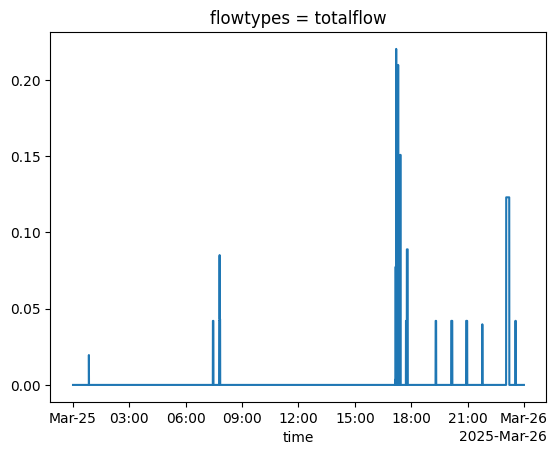

In [24]:
houses['1000002247166371'].consumption.sum(['enduse', 'user']).sel(flowtypes='totalflow').mean(['patterns']).plot()

In [25]:
hhs = list(houses.keys())
hhs

['1000002247166570',
 '1000002247166296',
 '1000002247166495',
 '1000002247166277',
 '1000002247166371',
 '1000002247166559',
 '1000002247166294',
 '1000002247166450',
 '1000002247166290',
 '1000002247166517']

In [26]:
filt_ad_filt = ad_filt[ad_filt['TOID'].isin(hhs)]

# Create a base map using the explore method on the subs GeoDataFrame
m = filt_ad_filt.explore(name='filt_ad_filt', column='occupancy_type')

# Add the ad points to the same map
subs.explore(m=m, name='subs')

# Add layer control to toggle between layers
folium.LayerControl().add_to(m)

# Display the map
m

In [27]:
filt_ad_filt = filt_ad_filt.sjoin(subs[['subcatchme', 'geometry']], how='inner')
filt_ad_filt

,TOID,occupancy_type,geometry,index_right,subcatchme
16,1000002247166290,one_person,POINT (340356.1 251561.4),42,SO40513504
17,1000002247166570,one_person,POINT (340497.2 251103.8),46,SO40514101.1
24,1000002247166450,one_person,POINT (340445.4 251302),48,SO40514301
26,1000002247166371,one_person,POINT (340617.8 251619.2),57,SO40515603
48,1000002247166559,two_person,POINT (340642.6 251254.2),63,SO40517304
51,1000002247166296,two_person,POINT (340244.5 251445.2),28,SO40512401
57,1000002247166294,two_person,POINT (340245.1 251437),28,SO40512401
81,1000002247166495,two_person,POINT (340507.4 251294),47,SO40514203
98,1000002247166277,family,POINT (340393.6 251536.8),42,SO40513504
119,1000002247166517,family,POINT (340537.5 251233.1),47,SO40514203


In [28]:
subcatchments = list(subs['subcatchme'].unique())
subcatchments

['Balance tank 2',
 'SO39516904',
 'SO39516912',
 'SO39516912.1',
 'SO39518902',
 'SO39518902.1',
 'SO39518902.2',
 'SO39518902.3',
 'SO39518902.4',
 'SO39519904',
 'SO39519905',
 'SO39519905.1',
 'SO39523101',
 'SO39524001',
 'SO39524002',
 'SO40510801',
 'SO40510801.1',
 'SO40510801.2',
 'SO40511501',
 'SO40511501.1',
 'SO40511601',
 'SO40511602',
 'SO40511602.1',
 'SO40511602.2',
 'SO40511701.1',
 'SO40511750',
 'SO40511801',
 'SO40511801.1',
 'SO40512401',
 'SO40512401.1',
 'SO40512401.2',
 'SO40512503',
 'SO40512504',
 'SO40512601',
 'SO40512602',
 'SO40512603',
 'SO40512651!',
 'SO40512701',
 'SO40512704',
 'SO40512801',
 'SO40512802',
 'SO40512802.1',
 'SO40513504',
 'SO40513702',
 'SO40513802',
 'SO40514101',
 'SO40514101.1',
 'SO40514203',
 'SO40514301',
 'SO40514403',
 'SO40514503',
 'SO40514704',
 'SO40514705',
 'SO40514801',
 'SO40515201',
 'SO40515502',
 'SO40515601!',
 'SO40515603',
 'SO40515603.1',
 'SO40515702',
 'SO40516201',
 'SO40516401',
 'SO40517204',
 'SO40517304'

In [29]:
# Iterate through each subcatchment
for sub in subcatchments:
    # Filter filt_ad_filt to find rows where 'subcatchme' matches the current sub
    toids_in_sub = filt_ad_filt[filt_ad_filt['subcatchme'] == sub]['TOID'].tolist()
    
    # Check if there are any TOIDs in the current subcatchment
    if len(toids_in_sub) > 0:
        print("add")
        print(f"Subcatchment: {sub}, TOIDs: {toids_in_sub}")

add
Subcatchment: SO40512401, TOIDs: ['1000002247166296', '1000002247166294']
add
Subcatchment: SO40513504, TOIDs: ['1000002247166290', '1000002247166277']
add
Subcatchment: SO40514101.1, TOIDs: ['1000002247166570']
add
Subcatchment: SO40514203, TOIDs: ['1000002247166495', '1000002247166517']
add
Subcatchment: SO40514301, TOIDs: ['1000002247166450']
add
Subcatchment: SO40515603, TOIDs: ['1000002247166371']
add
Subcatchment: SO40517304, TOIDs: ['1000002247166559']
